# Exploratory Data Analysis: Employee Motivation and Performance at Kerala Electrical & Allied Engineering Co. Ltd. (KEL)

**Author:** Joyal Joby (Jo)
**Institution:** The Kyoto College of Graduate Studies for Informatics
**Study site:** Kerala Electrical and Allied Engineering Co. Ltd., Mamala, Ernakulam, Kerala, India
**Sample:** n = 100 employees, primary survey data, 20 variables
**Study period:** 1–29 February 2024

## Overview

This notebook performs exploratory data analysis (EDA) on primary survey data collected to examine
the relationship between employee motivation, job satisfaction, and perceived performance at KEL.
The survey instrument captured 20 ordinal/categorical variables spanning compensation, recognition,
working conditions, career development, and management relations.

**Research questions**
1. What are the dominant satisfaction levels across HR dimensions (salary, recognition, working conditions, etc.)?
2. What is the relationship between employee motivation and job satisfaction?
3. What is the relationship between employee motivation and perceived performance?
4. Which factors are most strongly associated with overall motivation?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/kel_employee_survey_data.csv")
print(f"Dataset shape: {df.shape[0]} respondents x {df.shape[1]} variables")
df.head()


Dataset shape: 100 respondents x 21 variables


,Respondent_ID,Recognition_Satisfaction,Qualification_Influence,Experience_Influence,Motivation_Impact,Salary_Satisfaction,Supervisor_Feedback_Satisfaction,Monetary_Incentives_Satisfaction,Professional_Development,Performance_Appraisal_Satisfaction,...,Coworker_Relationship_Satisfaction,Working_Conditions_Satisfaction,Colleague_Support_Satisfaction,Promotion_Opportunities,Decision_Making_Participation,Nature_Of_Work_Perception,Management_Employee_Relationship,Respondent_Experience_Years,Motivating_Incentives_Type,Training_Programs_Satisfaction
0,R001,Satisfied,No influence,Moderate,Minor,Satisfied,Neutral,Satisfied,Excellent,Poor,...,Excellent,Neutral,Good,Sometimes,Poor,Good,Good,1-5 years,Both,Satisfied
1,R002,Satisfied,No influence,Minor,Minor,Neutral,Satisfied,Satisfied,Excellent,Neutral,...,Good,Good,Good,Seldom,Good,Good,Excellent,1-5 years,Both,Satisfied
2,R003,Satisfied,Moderate,Minor,Minor,Satisfied,Satisfied,Neutral,Good,Good,...,Good,Good,Poor,Seldom,Good,Good,Good,1-5 years,Both,Neutral
3,R004,Satisfied,Moderate,Significant,Minor,Satisfied,Dissatisfied,Dissatisfied,Poor,Neutral,...,Good,Neutral,Good,Often,Good,Poor,Good,5-10 years,Both,Satisfied
4,R005,Dissatisfied,Minor,No impact,Moderate,Dissatisfied,Dissatisfied,Dissatisfied,Neutral,Very Poor,...,Neutral,Neutral,Good,Sometimes,Good,Poor,Good,5-10 years,Both,Dissatisfied


## 1. Data Overview and Quality Checks

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Respondent_ID                       100 non-null    str  
 1   Recognition_Satisfaction            100 non-null    str  
 2   Qualification_Influence             100 non-null    str  
 3   Experience_Influence                100 non-null    str  
 4   Motivation_Impact                   100 non-null    str  
 5   Salary_Satisfaction                 100 non-null    str  
 6   Supervisor_Feedback_Satisfaction    100 non-null    str  
 7   Monetary_Incentives_Satisfaction    100 non-null    str  
 8   Professional_Development            100 non-null    str  
 9   Performance_Appraisal_Satisfaction  100 non-null    str  
 10  Job_Security_Satisfaction           100 non-null    str  
 11  Coworker_Relationship_Satisfaction  100 non-null    str  
 12  Working_Conditions_S

In [3]:
# Missing value check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected.")

# Duplicate check
print(f"\nDuplicate rows: {df.duplicated().subset if False else df.duplicated().sum()}")


Missing values per column:
No missing values detected.

Duplicate rows: 0


## 2. Respondent Profile

/tmp/ipykernel_615/4063960597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Respondent_Experience_Years", order=order, ax=ax, palette="viridis")


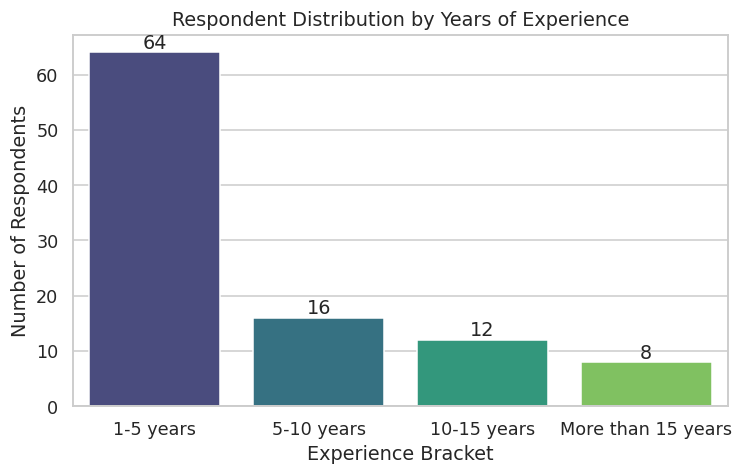

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["1-5 years", "5-10 years", "10-15 years", "More than 15 years"]
sns.countplot(data=df, x="Respondent_Experience_Years", order=order, ax=ax, palette="viridis")
ax.set_title("Respondent Distribution by Years of Experience")
ax.set_xlabel("Experience Bracket")
ax.set_ylabel("Number of Respondents")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.savefig("../reports/fig_experience_distribution.png", bbox_inches="tight")
plt.show()


/tmp/ipykernel_615/2584963969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Motivating_Incentives_Type", ax=ax, palette="mako",


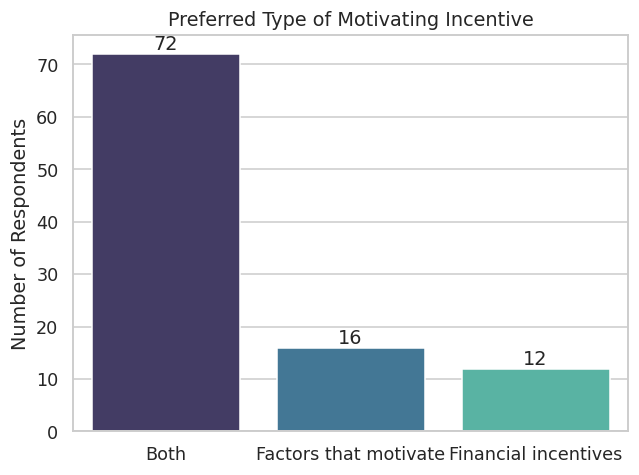

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.countplot(data=df, x="Motivating_Incentives_Type", ax=ax, palette="mako",
              order=df["Motivating_Incentives_Type"].value_counts().index)
ax.set_title("Preferred Type of Motivating Incentive")
ax.set_xlabel("")
ax.set_ylabel("Number of Respondents")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.savefig("../reports/fig_incentive_type.png", bbox_inches="tight")
plt.show()


## 3. Satisfaction Landscape Across HR Dimensions

To compare satisfaction across dimensions on a common scale, each 4–5 point ordinal variable is
mapped to a numeric score (e.g. Very Poor/Very Dissatisfied = 1 ... Excellent/Very Satisfied = 5,
Neutral = 3) so that mean scores can be ranked.


In [6]:
# Ordinal encoding maps (higher = more positive)
scale_5 = {
    "Very Poor": 1, "Very dissatisfied": 1, "Extremely dissatisfied": 1,
    "Poor": 2, "Dissatisfied": 2,
    "Neutral": 3,
    "Good": 4, "Satisfied": 4,
    "Excellent": 5, "Very Satisfied": 5, "Very satisfied": 5,
    "Extremely Satisfied": 5,
}

influence_scale = {"No influence": 1, "No impact": 1, "Minor": 2, "Moderate": 3, "Significant": 4}
frequency_scale = {"Never": 1, "Seldom": 2, "Sometimes": 3, "Often": 4, "Always": 5}

satisfaction_cols = [
    "Recognition_Satisfaction", "Salary_Satisfaction", "Supervisor_Feedback_Satisfaction",
    "Monetary_Incentives_Satisfaction", "Professional_Development",
    "Performance_Appraisal_Satisfaction", "Job_Security_Satisfaction",
    "Coworker_Relationship_Satisfaction", "Working_Conditions_Satisfaction",
    "Colleague_Support_Satisfaction", "Decision_Making_Participation",
    "Nature_Of_Work_Perception", "Management_Employee_Relationship",
    "Training_Programs_Satisfaction",
]

encoded = df.copy()
for c in satisfaction_cols:
    encoded[c + "_score"] = encoded[c].map(scale_5)

encoded["Promotion_Opportunities_score"] = encoded["Promotion_Opportunities"].map(frequency_scale)
encoded["Qualification_Influence_score"] = encoded["Qualification_Influence"].map(influence_scale)
encoded["Experience_Influence_score"] = encoded["Experience_Influence"].map(influence_scale)
encoded["Motivation_Impact_score"] = encoded["Motivation_Impact"].map(influence_scale)

score_cols = [c for c in encoded.columns if c.endswith("_score")]
mean_scores = encoded[score_cols].mean().sort_values(ascending=False)
mean_scores


Coworker_Relationship_Satisfaction_score    4.00
Colleague_Support_Satisfaction_score        3.88
Nature_Of_Work_Perception_score             3.84
Decision_Making_Participation_score         3.80
Management_Employee_Relationship_score      3.76
Recognition_Satisfaction_score              3.76
Working_Conditions_Satisfaction_score       3.68
Professional_Development_score              3.64
Supervisor_Feedback_Satisfaction_score      3.64
Performance_Appraisal_Satisfaction_score    3.52
Job_Security_Satisfaction_score             3.52
Training_Programs_Satisfaction_score        3.40
Salary_Satisfaction_score                   3.26
Monetary_Incentives_Satisfaction_score      3.16
Promotion_Opportunities_score               2.64
Qualification_Influence_score               2.20
Motivation_Impact_score                     2.20
Experience_Influence_score                  1.88
dtype: float64

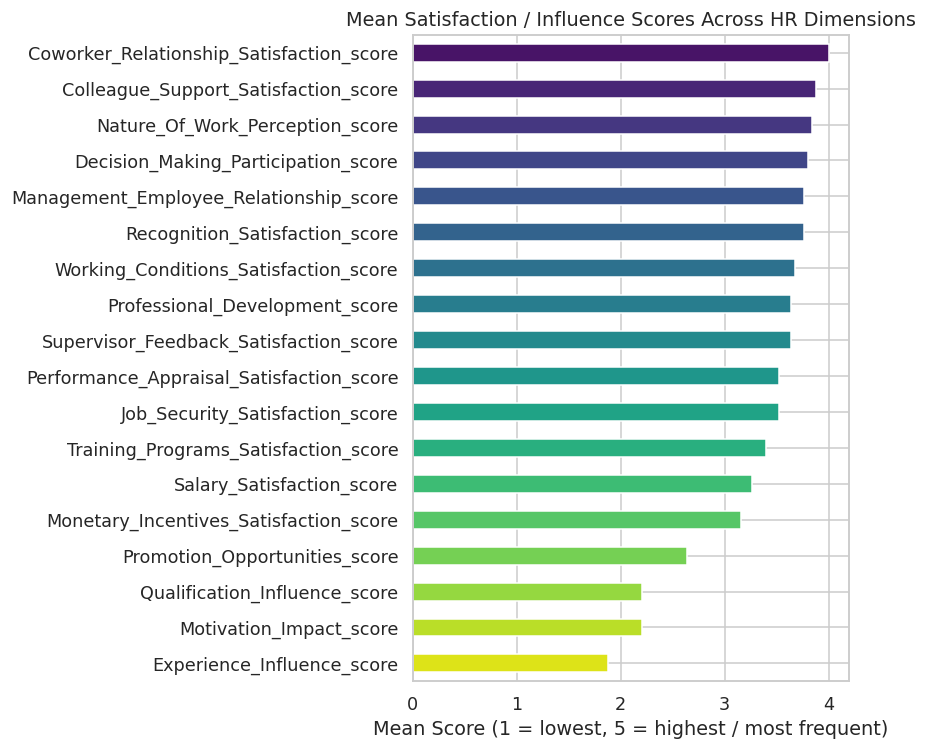

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_scores.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(mean_scores)))
ax.set_xlabel("Mean Score (1 = lowest, 5 = highest / most frequent)")
ax.set_title("Mean Satisfaction / Influence Scores Across HR Dimensions")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/fig_mean_scores_ranked.png", bbox_inches="tight")
plt.show()


## 4. Distribution of Key Satisfaction Variables

/tmp/ipykernel_615/4219904046.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="crest")
/tmp/ipykernel_615/4219904046.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="crest")
/tmp/ipykernel_615/4219904046.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="crest")
/tmp/ipykernel_615/4219904046.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

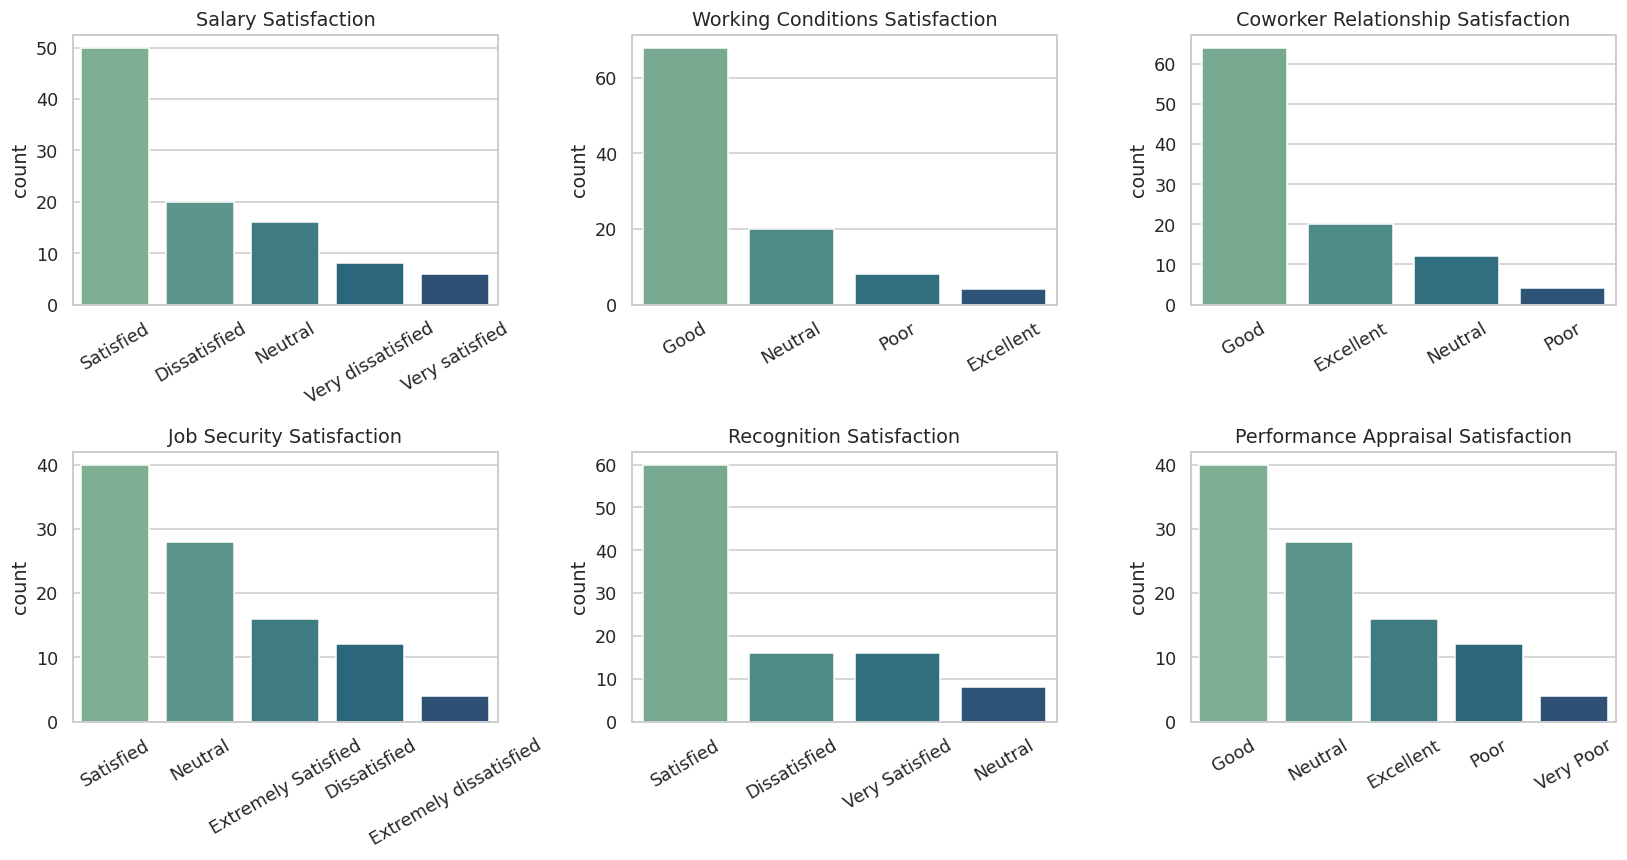

In [8]:
key_vars = ["Salary_Satisfaction", "Working_Conditions_Satisfaction",
            "Coworker_Relationship_Satisfaction", "Job_Security_Satisfaction",
            "Recognition_Satisfaction", "Performance_Appraisal_Satisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, key_vars):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="crest")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../reports/fig_key_satisfaction_distributions.png", bbox_inches="tight")
plt.show()


## 5. Relationship Between Motivation, Job Satisfaction and Performance

`Motivation_Impact` records each respondent's perception of how strongly motivation affects
their performance. This section tests its association with related variables using
cross-tabulation and the chi-square test of independence.


In [9]:
def chi_square_test(col_a, col_b, data=df):
    contingency = pd.crosstab(data[col_a], data[col_b])
    chi2, p, dof, expected = chi2_contingency(contingency)
    return contingency, chi2, p, dof

pairs = [
    ("Motivation_Impact", "Performance_Appraisal_Satisfaction"),
    ("Motivation_Impact", "Nature_Of_Work_Perception"),
    ("Motivation_Impact", "Recognition_Satisfaction"),
    ("Motivation_Impact", "Salary_Satisfaction"),
]

results = []
for a, b in pairs:
    _, chi2, p, dof = chi_square_test(a, b)
    results.append({"Variable A": a, "Variable B": b, "Chi-square": round(chi2, 3),
                     "df": dof, "p-value": round(p, 4),
                     "Significant (a=0.05)": "Yes" if p < 0.05 else "No"})

chi_results = pd.DataFrame(results)
chi_results


,Variable A,Variable B,Chi-square,df,p-value,Significant (a=0.05)
0,Motivation_Impact,Performance_Appraisal_Satisfaction,17.991,12,0.1160,No
1,Motivation_Impact,Nature_Of_Work_Perception,10.437,9,0.3163,No
2,Motivation_Impact,Recognition_Satisfaction,9.850,9,0.3628,No
3,Motivation_Impact,Salary_Satisfaction,11.163,12,0.5150,No


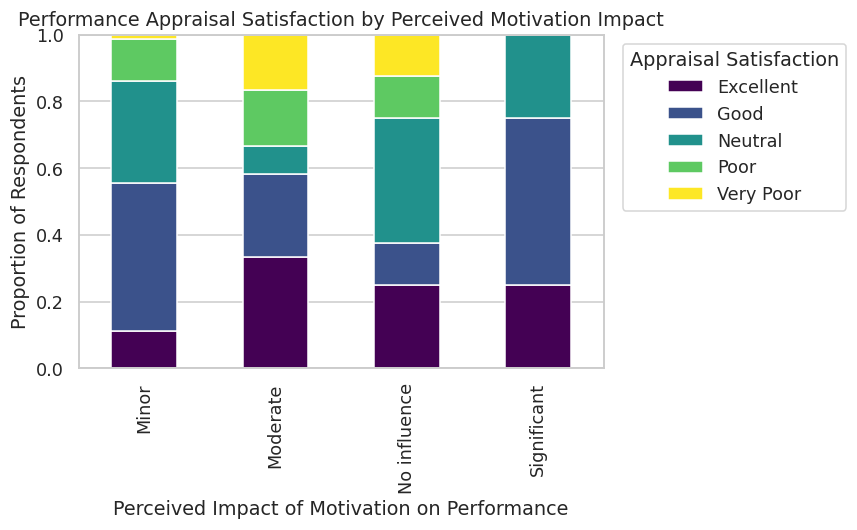

In [10]:
ct = pd.crosstab(df["Motivation_Impact"], df["Performance_Appraisal_Satisfaction"], normalize="index")
fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Performance Appraisal Satisfaction by Perceived Motivation Impact")
ax.set_xlabel("Perceived Impact of Motivation on Performance")
ax.set_ylabel("Proportion of Respondents")
ax.legend(title="Appraisal Satisfaction", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../reports/fig_motivation_vs_appraisal.png", bbox_inches="tight")
plt.show()


## 6. Correlation Structure Among Encoded Ordinal Variables

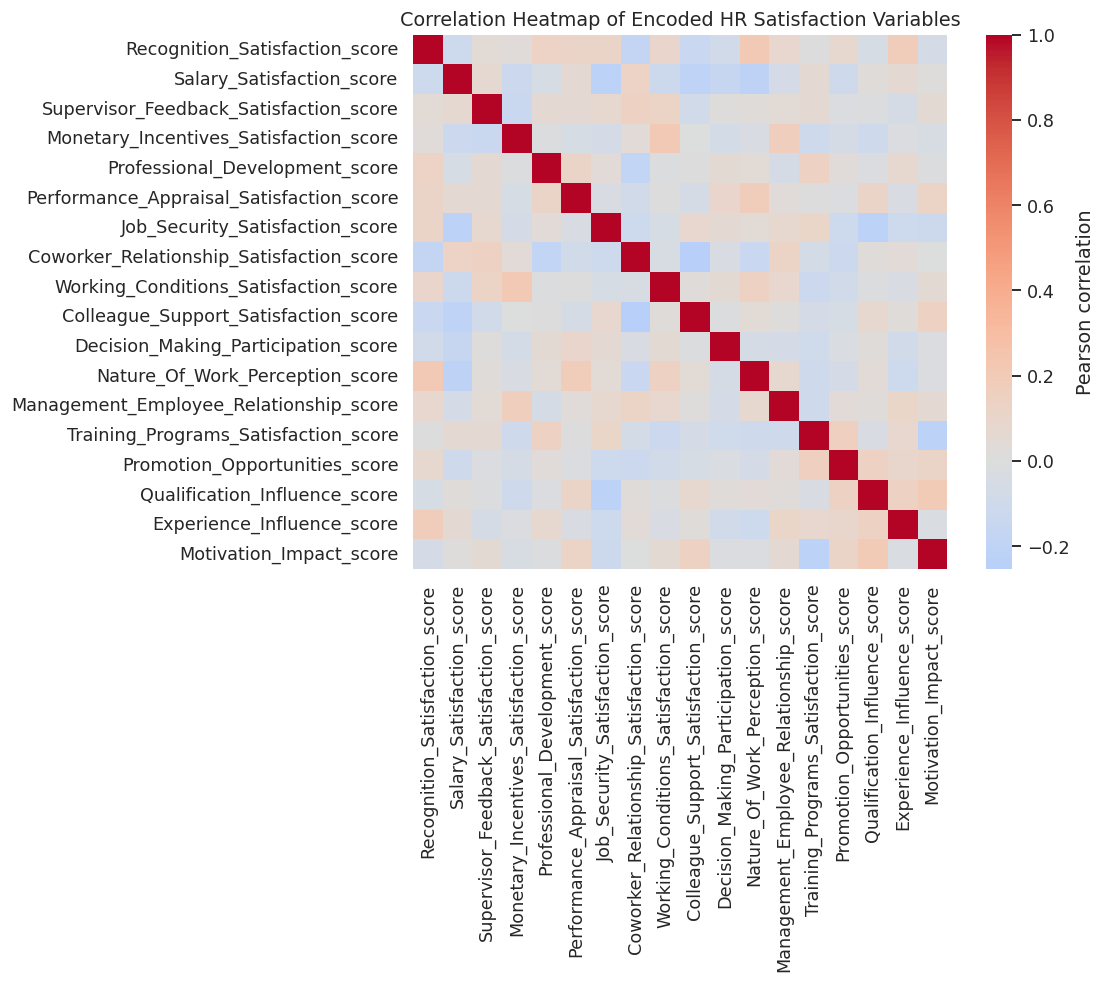

In [11]:
corr = encoded[score_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation Heatmap of Encoded HR Satisfaction Variables")
plt.tight_layout()
plt.savefig("../reports/fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [12]:
top_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("Top 10 strongest positive associations:")
top_corr.head(10)


Top 10 strongest positive associations:


Recognition_Satisfaction_score            Nature_Of_Work_Perception_score             0.213594
Monetary_Incentives_Satisfaction_score    Working_Conditions_Satisfaction_score       0.212767
Qualification_Influence_score             Motivation_Impact_score                     0.198464
Performance_Appraisal_Satisfaction_score  Nature_Of_Work_Perception_score             0.177852
Recognition_Satisfaction_score            Experience_Influence_score                  0.177331
Monetary_Incentives_Satisfaction_score    Management_Employee_Relationship_score      0.167678
Training_Programs_Satisfaction_score      Promotion_Opportunities_score               0.166321
Supervisor_Feedback_Satisfaction_score    Coworker_Relationship_Satisfaction_score    0.146116
Qualification_Influence_score             Experience_Influence_score                  0.144023
Promotion_Opportunities_score             Qualification_Influence_score               0.141988
dtype: float64

## 7. Incentive Preference by Experience Bracket

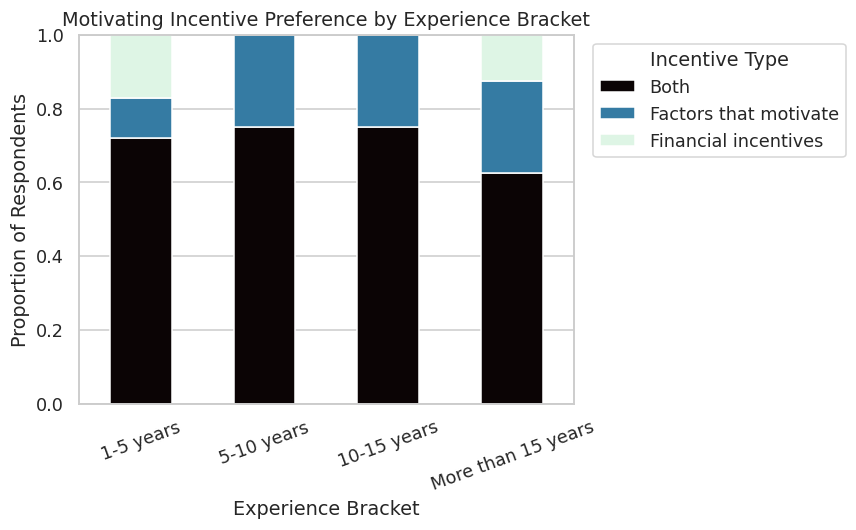

In [13]:
ct2 = pd.crosstab(df["Respondent_Experience_Years"], df["Motivating_Incentives_Type"], normalize="index")
ct2 = ct2.reindex(["1-5 years", "5-10 years", "10-15 years", "More than 15 years"])
fig, ax = plt.subplots(figsize=(8, 5))
ct2.plot(kind="bar", stacked=True, ax=ax, colormap="mako")
ax.set_title("Motivating Incentive Preference by Experience Bracket")
ax.set_ylabel("Proportion of Respondents")
ax.set_xlabel("Experience Bracket")
ax.legend(title="Incentive Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../reports/fig_incentive_by_experience.png", bbox_inches="tight")
plt.show()


## 8. Summary of Key EDA Findings

- Satisfaction with **working conditions**, **coworker relationships**, **colleague support**,
  and **training programs** ranks among the highest mean scores, consistent with the reported
  survey findings (~64–68% satisfied).
- **Promotion opportunities** and **performance appraisal** score comparatively lower,
  reflecting the reported dissatisfaction pockets (~40–44%) around career progression.
- The majority of respondents perceive **qualification and experience as having only a minor
  influence** on performance, while **motivation itself is also predominantly rated as a minor
  influence** — suggesting employees attribute performance to a broader mix of situational and
  managerial factors rather than any single driver.
- Cross-tabulations and chi-square tests are used to formally assess whether perceived
  motivation impact is statistically associated with appraisal satisfaction, work perception,
  recognition, and salary satisfaction (see Section 5 for exact test statistics).
- Employees preferring **both financial and non-financial incentives** dominate across all
  experience brackets, indicating a multidimensional reward strategy is appropriate at KEL.

These patterns are consistent with, and quantitatively substantiate, the findings reported in
Chapter 7 of the dissertation (*Employee Motivation and Performance: A Study at Kerala
Electrical and Allied Engineering Co. Ltd.*).
